In [11]:
# Necessary Libraries
import pandas as pd
import re
from factor_analyzer import FactorAnalyzer
from sklearn.preprocessing import MinMaxScaler
import seaborn as sns
import matplotlib.pyplot as plt


pd.set_option('display.max_columns', None)

In [3]:
df = pd.read_csv('data_exploration_data.csv')

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55 entries, 0 to 54
Data columns (total 10 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   country                      55 non-null     object 
 1   country_code                 55 non-null     object 
 2   year_gini                    55 non-null     int64  
 3   gini                         55 non-null     float64
 4   year_gdp_capita              55 non-null     int64  
 5   gdp_per_capita               55 non-null     float64
 6   happiness_score              55 non-null     float64
 7   year_oecd                    14 non-null     float64
 8   percent_gdp_social_spending  14 non-null     float64
 9   compassion_score             55 non-null     float64
dtypes: float64(6), int64(2), object(2)
memory usage: 4.4+ KB


In [5]:
df['country'].unique()

array(['Argentina', 'Armenia', 'Australia', 'Bangladesh', 'Bolivia',
       'Brazil', 'Canada', 'Chile', 'China', 'Colombia', 'Cyprus',
       'Czechia', 'Ecuador', 'Ethiopia', 'Germany', 'Greece', 'Guatemala',
       'India', 'Indonesia', 'Iran', 'Iraq', 'Japan', 'Jordan',
       'Kazakhstan', 'Kenya', 'Kyrgyzstan', 'Lebanon', 'Malaysia',
       'Mexico', 'Mongolia', 'Morocco', 'Myanmar', 'Netherlands',
       'Nicaragua', 'Nigeria', 'Pakistan', 'Peru', 'Philippines',
       'Romania', 'Russia', 'Serbia', 'Slovakia', 'South Korea',
       'Tajikistan', 'Thailand', 'Tunisia', 'Turkey', 'Ukraine',
       'United Kingdom', 'United States', 'Uruguay', 'Uzbekistan',
       'Vietnam', 'Zimbabwe'], dtype=object)

<Axes: xlabel='compassion_score', ylabel='Count'>

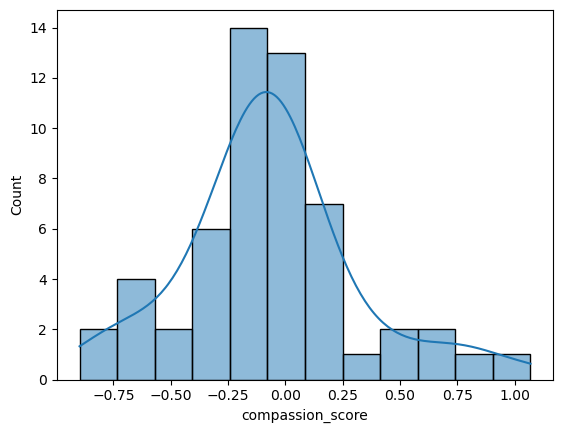

In [8]:
sns.histplot(df['compassion_score'], kde=True)

<Axes: xlabel='compassion_score', ylabel='gini'>

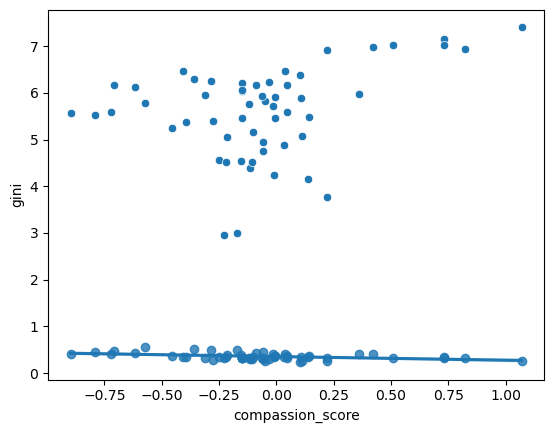

In [9]:
sns.scatterplot(data=df, x='compassion_score', y='happiness_score')
sns.regplot(data=df, x='compassion_score', y='gini')

<Axes: >

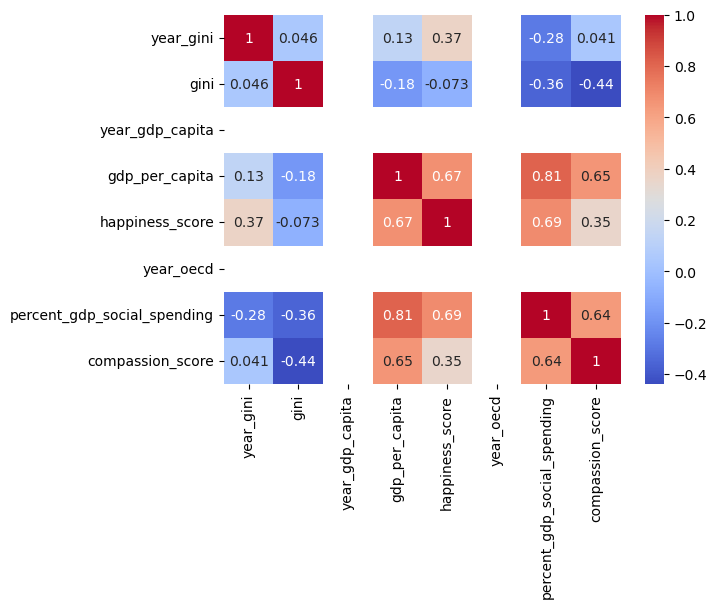

In [10]:
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')

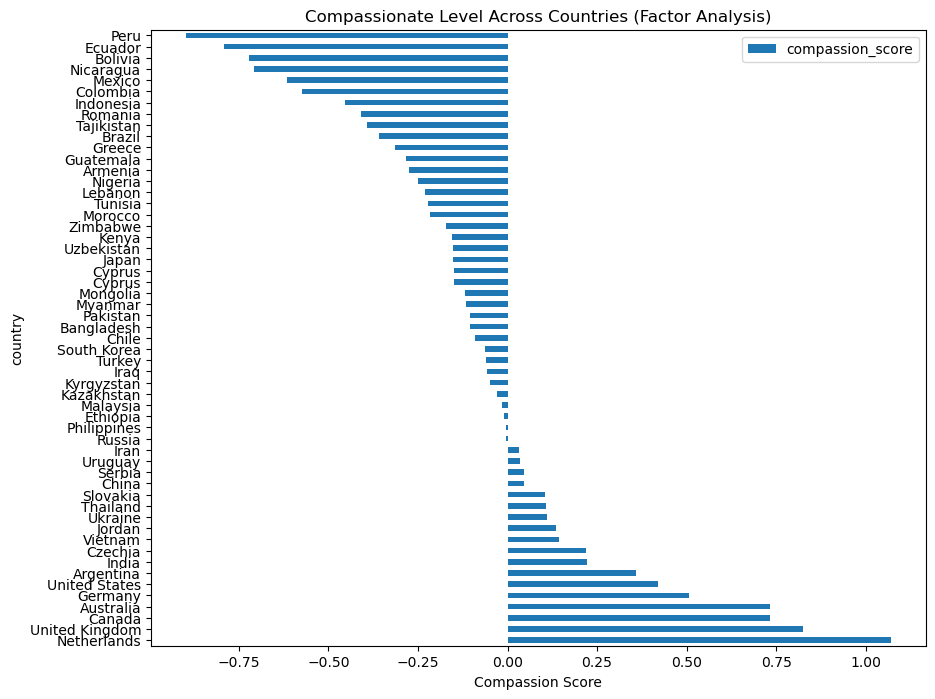

In [12]:
df.sort_values('compassion_score', ascending=False).plot(
    x='country', y='compassion_score', kind='barh', figsize=(10, 8))

plt.xlabel('Compassion Score')
plt.title('Compassionate Level Across Countries (Factor Analysis)')
plt.show()

In [13]:
from scipy.stats import pearsonr
pearsonr(df['compassion_score'], df['happiness_score'])

PearsonRResult(statistic=np.float64(0.3501671872365159), pvalue=np.float64(0.008772138163060784))

In [14]:
from scipy.stats import ttest_ind

high = df[df['compassion_score'] > df['compassion_score'].median()]['happiness_score']
low = df[df['compassion_score'] <= df['compassion_score'].median()]['happiness_score']

ttest_ind(high, low)

TtestResult(statistic=np.float64(1.9582351186029716), pvalue=np.float64(0.05547501188443035), df=np.float64(53.0))